In [2]:
import pandas as pd
import numpy as np

In [24]:
data_pursuits = pd.read_csv('data-processed/goal_pursuits.csv')
data_selections = pd.read_csv('data-processed/goal_selections.csv')
data_debrief = pd.read_csv('data-processed/debrief.csv')
selected_goals = pd.read_csv('data-processed/selected_goals_with_nll.csv')


In [25]:
selected_goals = selected_goals.drop(columns=['abandoned',
                                              'goal_achieved',
                                              'optimal_beta', 
                                              'conceptual_beta', 
                                              'optimal_total_nll', 
                                              'conceptual_total_nll', 
                                              'random_total_nll'], 
                                              axis=1)

In [27]:
selected_goals[selected_goals['participant_id'] == 'fake_id'].head(50)

,participant_id,trial_number,shape_0_type,shape_0_shade,shape_0_texture,shape_1_type,shape_1_shade,shape_1_texture,shape_2_type,shape_2_shade,shape_2_texture,optimal_choice_nll,random_choice_nll,conceptual_choice_nll
95,fake_id,1,square,medium,plain,square,medium,stripes,square,medium,dots,4.394449,9.887511,8.429931
96,fake_id,2,square,medium,dots,square,medium,plain,square,medium,stripes,4.394449,9.887511,8.429931
97,fake_id,3,square,medium,stripes,square,medium,dots,square,medium,plain,4.394449,9.887511,8.429931
98,fake_id,4,square,medium,stripes,square,medium,stripes,square,medium,dots,4.394449,9.887511,8.492045
99,fake_id,5,circle,medium,plain,circle,medium,stripes,circle,medium,dots,4.394449,9.887511,8.429931
100,fake_id,6,circle,medium,dots,circle,medium,plain,circle,medium,stripes,4.394449,9.887511,8.429931
101,fake_id,7,circle,medium,stripes,circle,medium,dots,circle,medium,plain,4.394449,9.887511,8.429931
102,fake_id,8,circle,medium,stripes,circle,medium,stripes,circle,medium,dots,4.394449,9.887511,8.492045
103,fake_id,9,triangle,medium,plain,triangle,medium,stripes,triangle,medium,dots,4.394449,9.887511,8.429931
104,fake_id,10,triangle,medium,dots,triangle,medium,plain,triangle,medium,stripes,4.394449,9.887511,8.429931


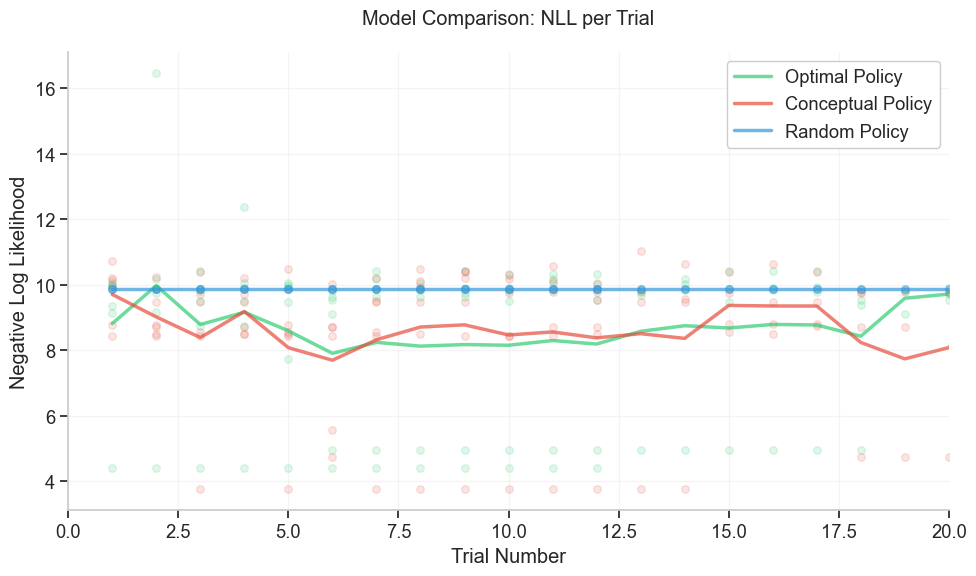

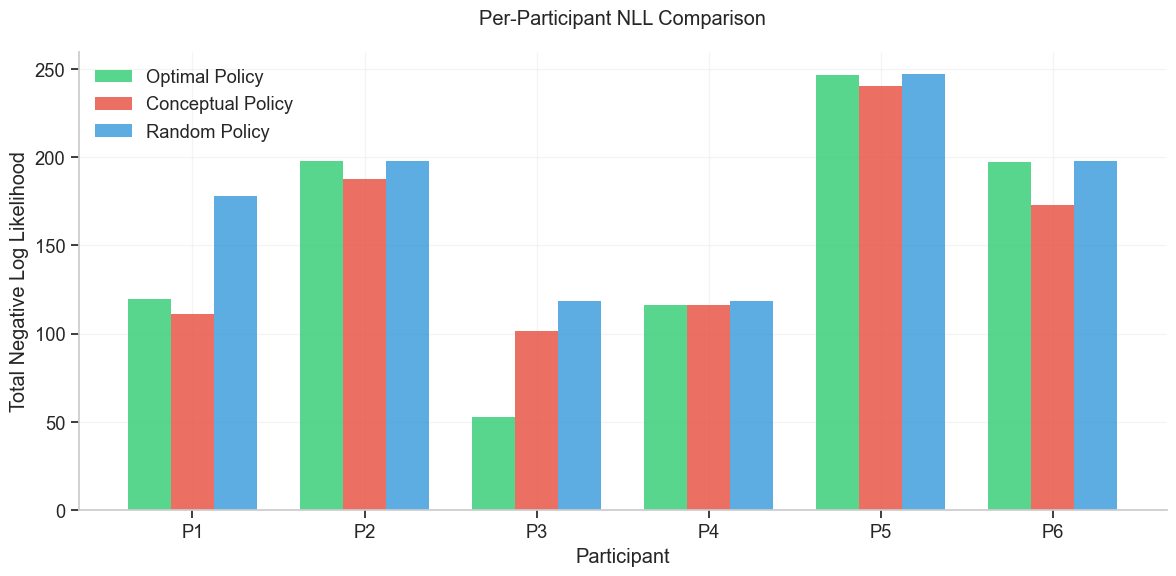


Mean NLL per trial:
Optimal Policy: 8.69
Conceptual Policy: 8.69
Random Policy: 9.89

Per-participant best fitting model:
Participant 1: Conceptual model preferred
Participant 2: Conceptual model preferred
Participant 3: Optimal model preferred
Participant 4: Conceptual model preferred
Participant 5: Conceptual model preferred
Participant 6: Conceptual model preferred


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# First plot: Trial-by-trial comparison
fig1, ax = plt.subplots(figsize=(10, 6))

# Define colors
colors = {
    'optimal': '#2ecc71',
    'conceptual': '#e74c3c',
    'random': '#3498db'
}

# Calculate trial means
trial_means = nll_data.groupby('trial_number').agg({
    'optimal_choice_nll': 'mean',
    'conceptual_choice_nll': 'mean',
    'random_choice_nll': 'mean'
}).reset_index()

# Plot mean lines first
ax.plot(trial_means['trial_number'], trial_means['optimal_choice_nll'], 
       '-', color=colors['optimal'], linewidth=2.5, alpha=0.7, label='Optimal Policy')
ax.plot(trial_means['trial_number'], trial_means['conceptual_choice_nll'], 
       '-', color=colors['conceptual'], linewidth=2.5, alpha=0.7, label='Conceptual Policy')
ax.plot(trial_means['trial_number'], trial_means['random_choice_nll'], 
       '-', color=colors['random'], linewidth=2.5, alpha=0.7, label='Random Policy')

# Plot individual points
ax.scatter(nll_data['trial_number'], nll_data['optimal_choice_nll'], 
         s=30, alpha=0.15, color=colors['optimal'])
ax.scatter(nll_data['trial_number'], nll_data['conceptual_choice_nll'], 
         s=30, alpha=0.15, color=colors['conceptual'])
ax.scatter(nll_data['trial_number'], nll_data['random_choice_nll'], 
         s=30, alpha=0.15, color=colors['random'])

# Clean up plot
ax.set_xlabel('Trial Number')
ax.set_ylabel('Negative Log Likelihood')
ax.set_title('Model Comparison: NLL per Trial', pad=20)
ax.legend(frameon=True, facecolor='white', framealpha=1)
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 20)  # Cap x-axis at 20 trials

plt.tight_layout()
plt.savefig('figures/model_comparison_per_trial.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Second plot: Per-participant bar comparison
fig2, ax = plt.subplots(figsize=(12, 6))

# Calculate participant totals
participant_totals = nll_data.groupby('participant_id').agg({
    'optimal_choice_nll': 'sum',
    'conceptual_choice_nll': 'sum',
    'random_choice_nll': 'sum'
}).reset_index()

# Set up bars
x = np.arange(len(participant_totals))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, participant_totals['optimal_choice_nll'], 
               width, label='Optimal Policy', color=colors['optimal'], alpha=0.8)
bars2 = ax.bar(x, participant_totals['conceptual_choice_nll'], 
               width, label='Conceptual Policy', color=colors['conceptual'], alpha=0.8)
bars3 = ax.bar(x + width, participant_totals['random_choice_nll'], 
               width, label='Random Policy', color=colors['random'], alpha=0.8)

# Clean up plot
ax.set_xlabel('Participant')
ax.set_ylabel('Total Negative Log Likelihood')
ax.set_title('Per-Participant NLL Comparison', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'P{i+1}' for i in range(len(participant_totals))])
ax.legend()
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/model_comparison_per_participant.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nMean NLL per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_nll'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_nll'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_nll'].mean():.2f}")

# Print per-participant statistics
print("\nPer-participant best fitting model:")
for idx, row in participant_totals.iterrows():
    nlls = {
        'Optimal': row['optimal_choice_nll'],
        'Conceptual': row['conceptual_choice_nll'],
        'Random': row['random_choice_nll']
    }
    best_model = min(nlls.items(), key=lambda x: x[1])[0]
    print(f"Participant {idx+1}: {best_model} model preferred")

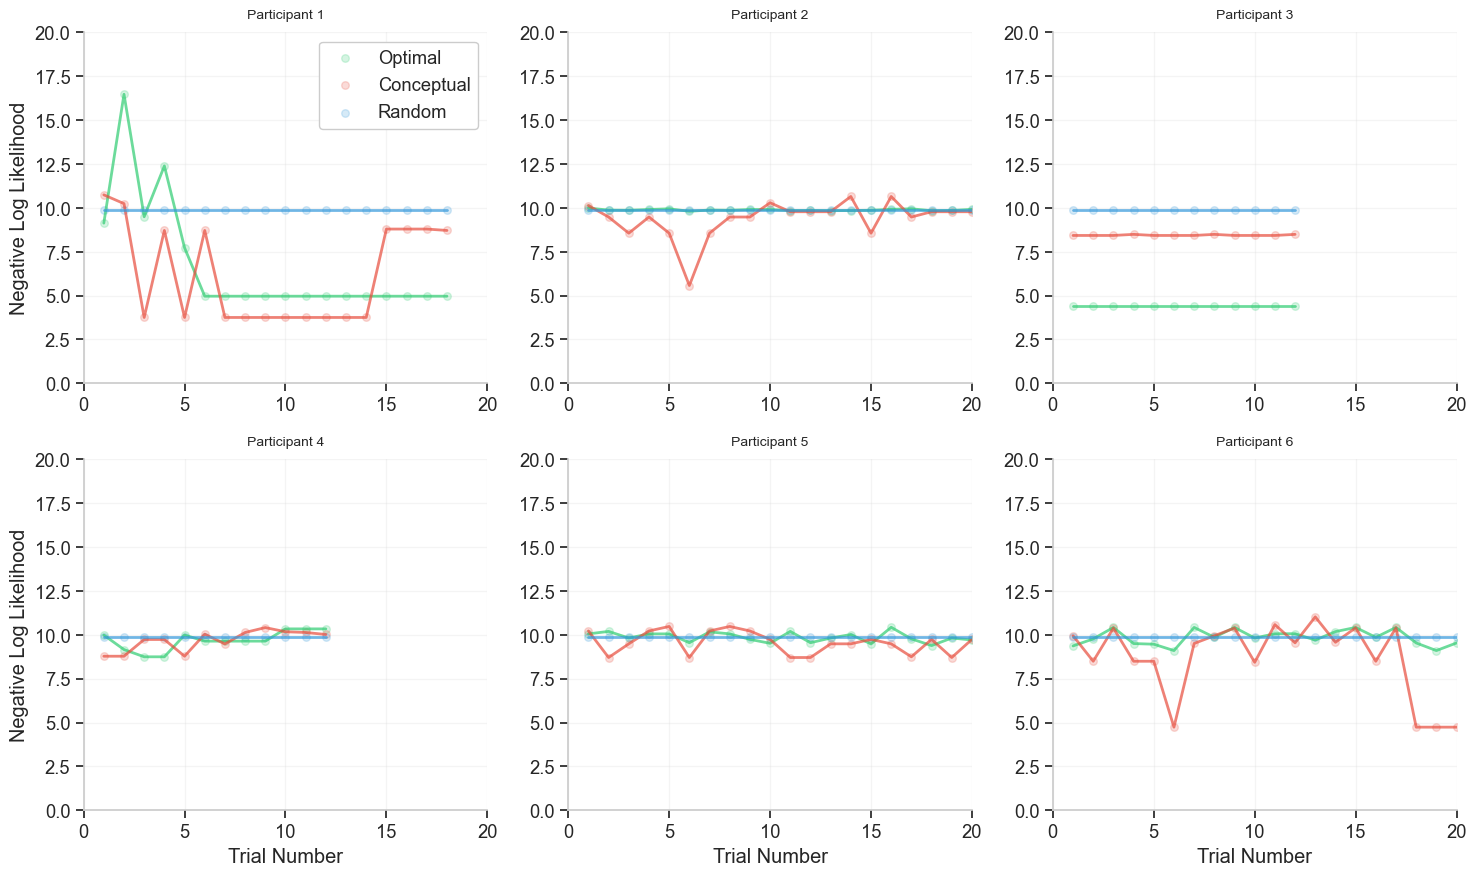

In [33]:
# Calculate and print per-participant faceted plot
n_participants = nll_data['participant_id'].nunique()
n_cols = 3
n_rows = (n_participants + n_cols - 1) // n_cols

fig3, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5*n_rows))
axes = axes.flatten()

for idx, (participant_id, participant_data) in enumerate(nll_data.groupby('participant_id')):
    ax = axes[idx]
    
    # Calculate means for this participant
    participant_means = participant_data.groupby('trial_number').agg({
        'optimal_choice_nll': 'mean',
        'conceptual_choice_nll': 'mean',
        'random_choice_nll': 'mean'
    }).reset_index()
    
    # Plot mean lines first
    ax.plot(participant_means['trial_number'], participant_means['optimal_choice_nll'],
           '-', color=colors['optimal'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['conceptual_choice_nll'],
           '-', color=colors['conceptual'], linewidth=2, alpha=0.7)
    ax.plot(participant_means['trial_number'], participant_means['random_choice_nll'],
           '-', color=colors['random'], linewidth=2, alpha=0.7)
    
    # Plot individual points
    ax.scatter(participant_data['trial_number'], participant_data['optimal_choice_nll'],
              s=30, alpha=0.2, color=colors['optimal'], label='Optimal')
    ax.scatter(participant_data['trial_number'], participant_data['conceptual_choice_nll'],
              s=30, alpha=0.2, color=colors['conceptual'], label='Conceptual')
    ax.scatter(participant_data['trial_number'], participant_data['random_choice_nll'],
              s=30, alpha=0.2, color=colors['random'], label='Random')
    
    # Calculate which model fits best
    nlls = {
        'Optimal': participant_data['optimal_choice_nll'].mean(),
        'Conceptual': participant_data['conceptual_choice_nll'].mean(),
        'Random': participant_data['random_choice_nll'].mean()
    }
    best_model = min(nlls.items(), key=lambda x: x[1])[0]
    
    # Clean up axes
    ax.set_xlabel('Trial Number' if idx >= len(axes) - n_cols else '')
    ax.set_ylabel('Negative Log Likelihood' if idx % n_cols == 0 else '')
    ax.set_title(f'Participant {idx+1}', fontsize=10, pad=10)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 20)  # Cap x-axis at 20 trials
    ax.set_ylim(0,20)  # Use same y-axis limits
    
    # Only add legend to first subplot
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=1)

# Remove any empty subplots
for idx in range(n_participants, len(axes)):
    fig3.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('figures/per_participant_faceted.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/qr/gb70fn114p97s4wfdyrjqlv40000gp/T/ipykernel_87555/3672218403.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


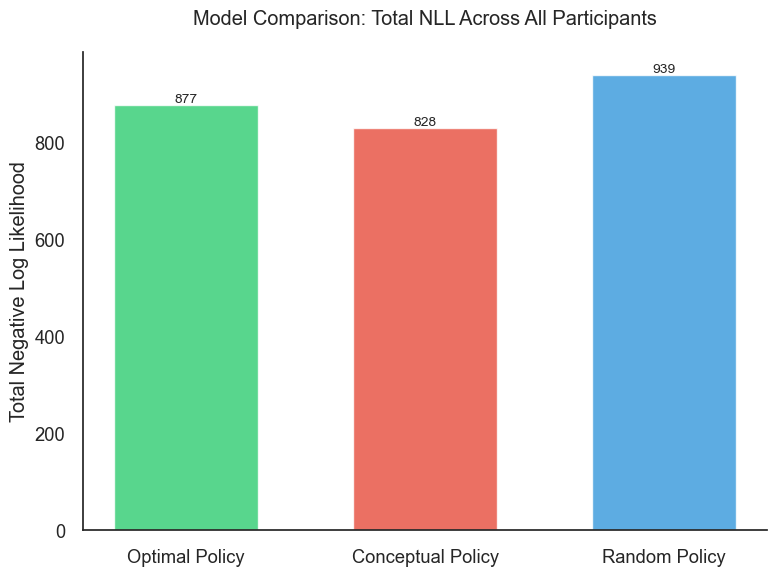


Total NLL:
Optimal Policy: 877
Conceptual Policy: 828
Random Policy: 939

Mean NLL per trial:
Optimal Policy: 9.23
Conceptual Policy: 8.72
Random Policy: 9.89


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean background
plt.style.use('seaborn')
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# Calculate total NLLs
total_nlls = {
    'Optimal Policy': nll_data['optimal_choice_nll'].sum(),
    'Conceptual Policy': nll_data['conceptual_choice_nll'].sum(),
    'Random Policy': nll_data['random_choice_nll'].sum()
}

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors
colors = {
    'Optimal Policy': '#2ecc71',
    'Conceptual Policy': '#e74c3c',
    'Random Policy': '#3498db'
}

# Create bars
bars = ax.bar(total_nlls.keys(), total_nlls.values(), 
              color=[colors[k] for k in total_nlls.keys()], 
              alpha=0.8, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}',
            ha='center', va='bottom', fontsize=10)

# Clean up plot
ax.set_ylabel('Total Negative Log Likelihood')
ax.set_title('Model Comparison: Total NLL Across All Participants', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save and show plot
plt.savefig('figures/overall_model_comparison.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nTotal NLL:")
for model, total in total_nlls.items():
    print(f"{model}: {total:,.0f}")

print("\nMean NLL per trial:")
print(f"Optimal Policy: {nll_data['optimal_choice_nll'].mean():.2f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_nll'].mean():.2f}")
print(f"Random Policy: {nll_data['random_choice_nll'].mean():.2f}")